
<font size = "5"> **Chapter 2: [Diffraction](../Diffraction/CH2_00-Diffraction.ipynb)** </font>

<hr style="height:1px;border-top:4px solid #FF8200" />

# Homework 07:  Analyzing CBED Pattern in Two Beam Condition

[Download](https://raw.githubusercontent.com/gduscher/MSE672-Introduction-to-TEM//main/Homework/Homework07.ipynb)


[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
    https://colab.research.google.com/github/gduscher/MSE672-Introduction-to-TEM/blob/main/Homework/Homework07.ipynb)


 
part of 

<font size = "5"> **[MSE672:  Introduction to Transmission Electron Microscopy](../_MSE672_Intro_TEM.ipynb)**</font>

by Gerd Duscher, Spring 2026

Microscopy Facilities<br>
Institute of Advanced Materials & Manufacturing<br>
Materials Science & Engineering<br>
The University of Tennessee, Knoxville

Background and methods to analysis and quantification of data acquired with transmission electron microscopes


## Load relevant python packages
### Check Installed Packages

In [17]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

# pyTEMlib setup ------------------
if test_package('pyTEMlib') < '0.2026.1.3':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install  --upgrade pyTEMlib -q
# ------------------------------
print('done')

done


### Import numerical and plotting python packages
Import the python packages that we will use:

Beside the basic numerical (numpy) and plotting (pylab of matplotlib) libraries,

and some libraries from the book
* kinematic scattering library.
* file_tools library

In [2]:
%matplotlib  widget
import sys

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy


if 'google.colab' in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
    from google.colab import drive

import pyTEMlib

__notebook_version__ = '2026.03.05'

print('pyTEM version: ', pyTEMlib.__version__)
print('notebook version: ', __notebook_version__)

pyTEM version:  0.2026.1.3
notebook version:  2026.03.05


## Load CBED Pattern from Lab 5

First we select the diffraction pattern

In [4]:
# ------Input -------------
load_your_own_data = True
# -------------------------
if 'google.colab' in sys.modules:
    drive.mount("/content/drive")
    load_your_own_data = True
if load_your_own_data:
   fileWidget = pyTEMlib.file_tools.FileWidget(sum_frames=True)
    

### Plotting on a logarithmic scale

The dynamic range in diffraction data is even larger than in images and so for a good presentation of the data it is advantagous to go to plot the intensities in a logarythmic scale.

To present data in logarythmic scale no nexgative values (noise) can be in these data and so all negative values in the dataset will be set to zero.

The factor 1 in front of the diffraction pattern in the log numpy function in the ``imshow`` is the gamma value.
Changing that value will change the contrast.

[np.float64(-0.003673379775136709), np.float64(15.042490179184824), np.float64(15.042490179184824), np.float64(-0.003673379775136709)]


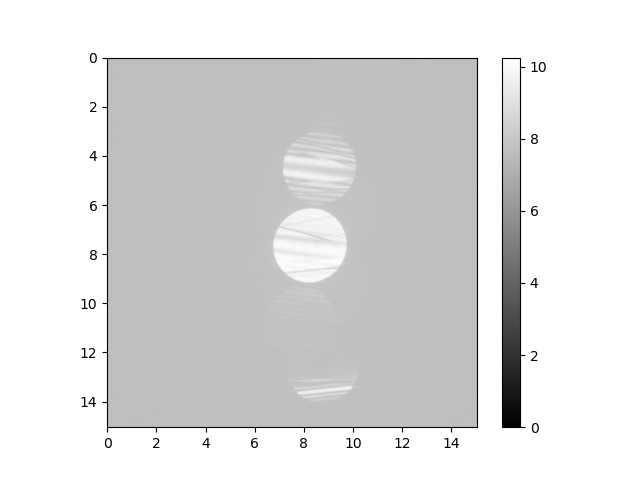

In [6]:
diff_pattern = fileWidget.selected_dataset
diff_pattern -= diff_pattern.min()

diff_pattern[diff_pattern<0] = 0.
extent = diff_pattern.get_extent([0,1])
print(extent)
fig = plt.figure() 
plt.imshow(np.log(1+diff_pattern).T,cmap="gray", extent=extent);
plt.colorbar();

## Getting Bragg angle

### Selection of Bragg angle

Select the Bragg angle with the line, make sure that the selection is perpendicular to the profile you want.

It is a good idea to fist zoom in to the relevant part of the diffraction pattern.


15

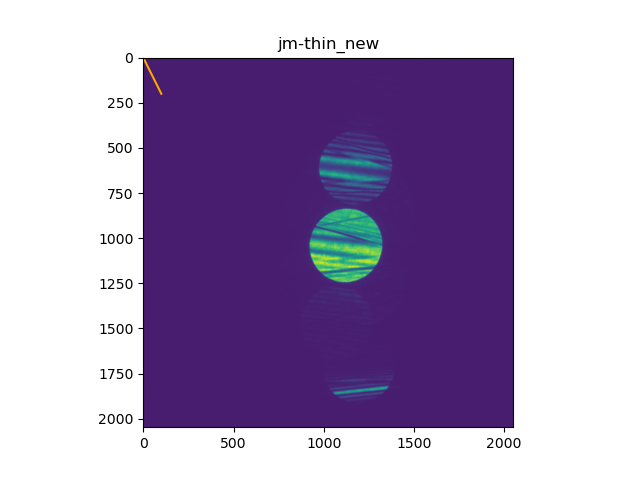

In [7]:
fig = plt.figure()

plt.imshow(diff_pattern.T)
plt.title(diff_pattern.title)
ax = plt.gca()
start_x = 0

fixed_line = False
line = plt.plot([0, 100],[0,200], color = 'orange')


def on_click(event):
   
    if event.inaxes:
        (start_x, end_x), (start_y, end_y) = line[0].get_data()
        start_x = end_x
        start_y = end_y
        end_x = event.xdata
        end_y = event.ydata

        line[0].set_data([start_x, end_x],[start_y, end_y])

        plt.draw()
# mouse_reference = plt.connect('motion_notify_event', on_move)
fig.canvas.mpl_connect('button_press_event', on_click)

### The angle of the profile and Bragg angle will be determined here

In [8]:
line_coordinates = np.array(line[0].get_data()).T
vector = line_coordinates[0]-line_coordinates[1]
length = np.linalg.norm(vector)
angle = np.degrees(np.arctan2(vector[1], vector[0]))%180
print(f' The line is {np.linalg.norm(vector):.2f}pixels = {length*diff_pattern.u.slope:.2f} 1/nm long')
print(f' The angle is {np.degrees(np.arctan2(vector[1], vector[0]))%180:.2f} degrees')

 The line is 454.45pixels = 3.34 1/nm long
 The angle is 97.29 degrees


## Plot totated CBED pattern and select area for profile

C:\Users\gduscher\AppData\Local\Temp\ipykernel_34888\909185590.py:1: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc, ndimage


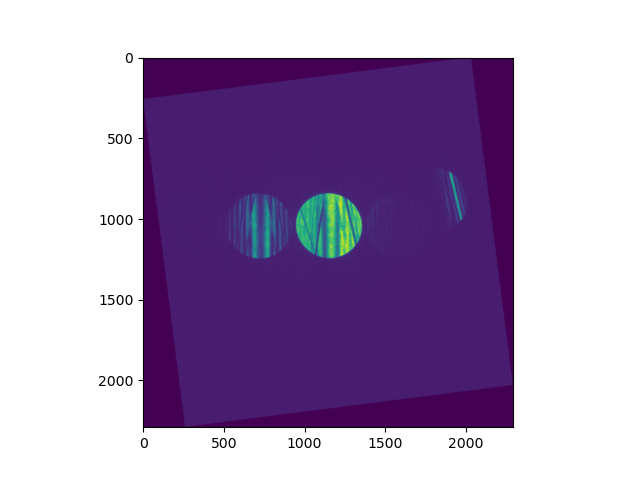

In [9]:

rotated_cbed = scipy.ndimage.rotate(diff_pattern.T, angle)
plt.figure()
plt.imshow(rotated_cbed)
plt.show()
selector = matplotlib.widgets.RectangleSelector(plt.gca(), None,interactive=True )  # gca get current axis (plot)

#selector.to_draw.set_visible(True)

### Show selection

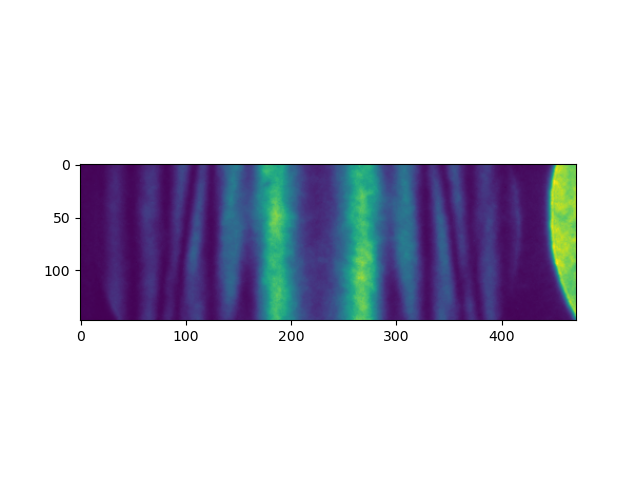

In [11]:
xmin, xmax, ymin, ymax = selector.extents
selection = rotated_cbed[int(ymin):int(ymax), int(xmin):int(xmax)]
plt.figure()
plt.imshow(selection)


### Plot Profile and select to measure distances

You should determine the distance between two equivalent minima (left and right of line with zero excitation error)

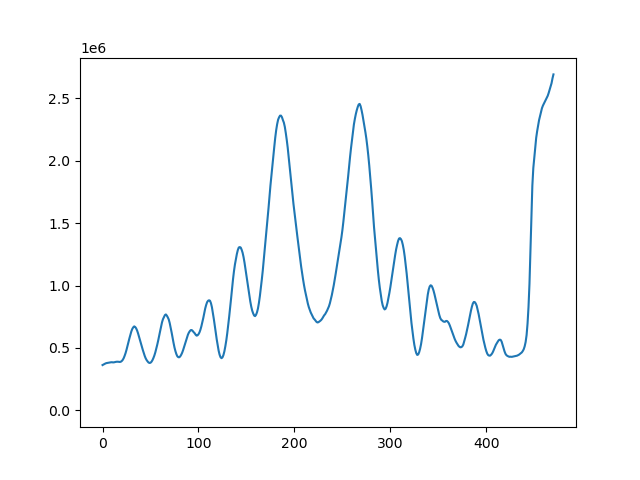

In [14]:
plt.figure()
plt.plot(selection.sum(axis=0))
selector_profile = RectangleSelector(plt.gca(), None,interactive=True) 


### Run code cell below to determine distance of selection in profile

Note: you'll have to do this a few times to determine the oscillations

In [15]:
xmin, xmax, ymin, ymax = selector_profile.extents
print(f'distance is {xmax-xmin} pixels = {(xmax-xmin)*diff_pattern.u.slope:.3f} {diff_pattern.u.units}')

distance is 133.4193548387097 pixels = 0.980 1/nm


## Homework

> STEP 1: MEASURE THE BRAGG ANGLE
1. Measure the distance of the double Bragg angle in pixel and put this value in a Excel spreadsheet.
2. Enter all the necessary constants: $\lambda$ and the lattice plane distance d
3. Measure the distance of each bright line from the center line and put it in a table in that Excel spread sheet. Use $\theta_i$ and $n$ as column heads.

> STEP 2: CALCULATE THE EXCITATION ERROR

Calculate the excitation error $s_i$ for all minima in the diffracted disk with ¸ $\lambda =$ 2.5 pm and d for the [200] lattice planes according to the following formula:

$$ s_i = \frac{\Delta \theta_i}{2\theta_B \cdot d^2} \cdot \lambda
$$

Do it in a table format ( the running number is one column).

> STEP 3: DETERMINE THICKNESS AND EXCTINCTION DISTANCE FROM A PLOT

Plot (s$_i$/$n_k$ )$^2$ versus (1/$n_k$)$^2$.


Note that the line must have a negative slope (you will need to increase starting values of $n_k$ till slope is negative)

Then:
*the slope of the line is $-1/\xi_g^2$
*the extrapolated value for $1/n_k^2$=0 is $1/t^2$

## Note

>The extinction distance is a unique materials parameter

## Conclusion

* Two-beam condition (necessary for conventional TEM) is easily reached with the help of Kikuchi lines.

* We can determine the thickness very accurately, a necessary value for many image and diffraction analysis methods.
